# 12.01 Particle Filter & MCL 실습 — 맵 위에서 로봇 위치 찾아가기

**목표:** ROS2의 AMCL 핵심 원리(초기화 → 예측 → 관측 → 리샘플링)를 
Python 시뮬레이션으로 단계별로 체감합니다.

## Step 1 — 시뮬레이션 환경 & 맵(Occupancy Grid) 준비

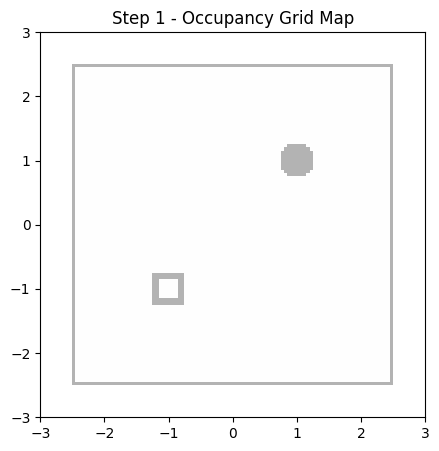

✅ Step 1 완료 - 맵 생성 완료


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# 상수 설정
ROOM_LIMIT = 2.5
MOVE_DIST = 0.4
ODOM_NOISE_RATIO = 0.25
LIDAR_RANGE = 3.5
LIDAR_RAYS = 36
MAP_RES = 0.05
MAP_SIZE = int((ROOM_LIMIT * 2) / MAP_RES)

# 환경 정의 (벽과 장애물)
SEGMENTS = [
    np.array([[-2.5, -2.5], [ 2.5, -2.5]]), np.array([[-2.5,  2.5], [ 2.5,  2.5]]), # 남, 북
    np.array([[-2.5, -2.5], [-2.5,  2.5]]), np.array([[ 2.5, -2.5], [ 2.5,  2.5]]), # 서, 동
    np.array([[-1.2, -1.2], [-0.8, -1.2]]), np.array([[-0.8, -1.2], [-0.8, -0.8]]), # 박스
    np.array([[-0.8, -0.8], [-1.2, -0.8]]), np.array([[-1.2, -0.8], [-1.2, -1.2]]),
]
CYLINDER = {'x': 1.0, 'y': 1.0, 'r': 0.2}

def build_map():
    """간단한 Ray-casting용 2D Occupancy Grid 생성"""
    grid = np.zeros((MAP_SIZE, MAP_SIZE), dtype=np.int8)
    for cy in range(MAP_SIZE):
        for cx in range(MAP_SIZE):
            x = -ROOM_LIMIT + (cx + 0.5) * MAP_RES
            y = -ROOM_LIMIT + (cy + 0.5) * MAP_RES
            occ = False
            for seg in SEGMENTS:
                p1, p2 = seg[0], seg[1]
                px, py = p2[0]-p1[0], p2[1]-p1[1]
                norm2 = px*px + py*py
                t = max(0, min(1, ((x-p1[0])*px + (y-p1[1])*py) / norm2)) if norm2 > 0 else 0
                if np.hypot(x - (p1[0]+t*px), y - (p1[1]+t*py)) < 0.06:
                    occ = True; break
            if not occ and np.hypot(x - CYLINDER['x'], y - CYLINDER['y']) < CYLINDER['r'] + 0.06:
                occ = True
            grid[cy, cx] = 100 if occ else 0
    return grid

occupancy_grid = build_map()

def draw_map(ax, title="Room Map"):
    ax.imshow(occupancy_grid, origin='lower', cmap='gray_r',
              extent=[-ROOM_LIMIT, ROOM_LIMIT, -ROOM_LIMIT, ROOM_LIMIT], 
              vmin=-1, vmax=100, alpha=0.3)
    ax.set_title(title); ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)

fig, ax = plt.subplots(figsize=(5, 5))
draw_map(ax, "Step 1 - Occupancy Grid Map")
plt.show()

print("✅ Step 1 완료 - 맵 생성 완료")

## Step 2 — 2D 변환 행렬 & LiDAR 시뮬레이션

In [2]:
def v2t(v):
    c, s = np.cos(v[2]), np.sin(v[2])
    return np.array([[c, -s, v[0]], [s, c, v[1]], [0, 0, 1]])

def t2v(T):
    return np.array([T[0,2], T[1,2], np.arctan2(T[1,0], T[0,0])])

def pose_compose(xi, xj): return t2v(v2t(xi) @ v2t(xj))
def relative_pose(xi, xj): return t2v(np.linalg.inv(v2t(xi)) @ v2t(xj))

def ray_cast(pose, angle):
    ox, oy = pose[0], pose[1]
    dx, dy = np.cos(pose[2]+angle), np.sin(pose[2]+angle)
    closest = LIDAR_RANGE
    for seg in SEGMENTS:
        x1, y1, x2, y2 = *seg[0], *seg[1]
        denom = dx*(y1-y2) - dy*(x1-x2)
        if abs(denom) < 1e-9: continue
        t = ((x1-ox)*(y1-y2) - (y1-oy)*(x1-x2)) / denom
        u = -((x1-ox)*dy - (y1-oy)*dx) / denom
        if t > 0 and 0 <= u <= 1 and t < closest: closest = t
            
    cx, cy, cr = CYLINDER['x'], CYLINDER['y'], CYLINDER['r']
    a, b, c = dx**2+dy**2, 2*(ox-cx)*dx + 2*(oy-cy)*dy, (ox-cx)**2+(oy-cy)**2 - cr**2
    disc = b**2 - 4*a*c
    if disc >= 0:
        for t in [(-b - np.sqrt(disc))/(2*a), (-b + np.sqrt(disc))/(2*a)]:
            if t > 0 and t < closest: closest = t
    return closest

def get_scan(pose, angle_offset=0):
    """angle_offset: 방향 보정용 (파티클의 방향 차이를 보정할 때 사용)"""
    return np.array([ray_cast(pose, a + angle_offset) for a in np.linspace(0, 2*np.pi, LIDAR_RAYS, endpoint=False)])

print("✅ Step 2 완료 - 수학 유틸리티 준비")

✅ Step 2 완료 - 수학 유틸리티 준비


## Step 3 — 로봇 이동 궤적 생성 (GT vs Odom)

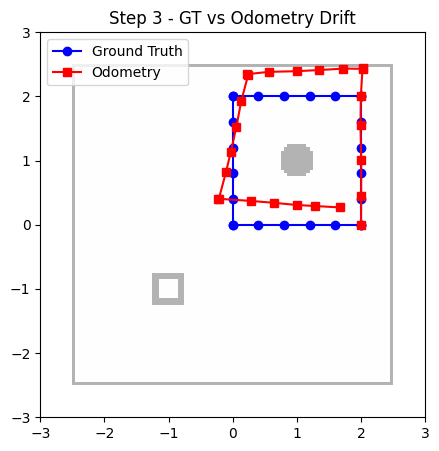

In [3]:
def noisy_odometry(true_delta, noise=ODOM_NOISE_RATIO):
    n = np.random.randn(3) * noise * np.maximum(np.abs(true_delta), 0.05)
    n[2] *= 0.5; return true_delta + n

# 원통(1.0, 1.0) 주변을 도는 사각형 경로
# 동쪽(2.0, 0.0~2.0) → 북쪽(0.0~2.0, 2.0) → 서쪽(0.0, 2.0~0.0) → 남쪽(0.0~2.0, 0.0)
gt_poses = [np.array([2.0, 0.0, np.pi/2])]  # 시작: 원통 남동쪽, 북쪽(위)을 바라봄
for side in range(4):
    for _ in range(5): gt_poses.append(pose_compose(gt_poses[-1], [MOVE_DIST, 0, 0]))
    if side < 3: gt_poses.append(pose_compose(gt_poses[-1], [0, 0, np.pi/2]))
gt_poses = np.array(gt_poses)

odom_poses, odom_deltas = [gt_poses[0].copy()], []
for i in range(1, len(gt_poses)):
    meas = noisy_odometry(relative_pose(gt_poses[i-1], gt_poses[i]))
    odom_deltas.append(meas)
    odom_poses.append(pose_compose(odom_poses[-1], meas))
odom_poses = np.array(odom_poses)

fig, ax = plt.subplots(figsize=(5,5))
draw_map(ax, "Step 3 - GT vs Odometry Drift")
ax.plot(gt_poses[:,0], gt_poses[:,1], 'b-o', label='Ground Truth')
ax.plot(odom_poses[:,0], odom_poses[:,1], 'r-s', label='Odometry')
ax.legend(); plt.show()

## Step 4 — MCL (파티클 필터) 핵심 알고리즘 정의

In [4]:
def init_particles(n, grid=None, true_pose=None):
    """파티클 초기화 (Global: 맵 전체 무작위 / Local: 시작 위치 근처)"""
    if true_pose is not None:
        xs = np.random.normal(true_pose[0], 0.2, n)
        ys = np.random.normal(true_pose[1], 0.2, n)
        ths = np.random.normal(true_pose[2], 0.1, n)
    else:
        free_y, free_x = np.where(grid == 0)
        idx = np.random.choice(len(free_x), size=n)
        xs = -ROOM_LIMIT + (free_x[idx] + 0.5) * MAP_RES
        ys = -ROOM_LIMIT + (free_y[idx] + 0.5) * MAP_RES
        ths = np.random.uniform(-np.pi, np.pi, size=n)
    return np.column_stack([xs, ys, ths]), np.ones(n)/n

def motion_update(particles, odom_delta):
    """1. 예측 (Motion Update): 파티클 이동 + 노이즈 (직진/회전 모두 반영)"""
    updated = []
    for p in particles:
        # 위치 노이즈는 최소 5cm 보장, 회전 노이즈는 더 작게
        noise = np.random.randn(3) * np.maximum(np.abs(odom_delta), 0.05)
        noise[:2] *= 0.15   # x,y 노이즈
        noise[2] *= 0.10    # 회전 노이즈
        updated.append(pose_compose(p, odom_delta + noise))
    return np.array(updated)

def sensor_update(particles, true_scan, true_pose):
    """2. 관측 (Sensor Update): 방향을 GT와 동일하게 맞춘 후 LiDAR 비교 → 가중치 계산"""
    weights = np.zeros(len(particles))
    for i, p in enumerate(particles):
        # 파티클 방향과 GT 방향의 차이만큼 스캔을 회전시켜 비교
        # (방향이 틀린 파티클도 위치만 맞으면 같은 스캔 패턴을 보여야 함)
        dtheta = p[2] - true_pose[2]
        pred_scan = get_scan(p, angle_offset=-dtheta)
        valid = (true_scan < LIDAR_RANGE - 0.1) & (pred_scan < LIDAR_RANGE - 0.1)
        if valid.sum() < 5:
            weights[i] = 1e-10; continue
        diff = true_scan[valid] - pred_scan[valid]
        weights[i] = max(np.exp(-0.5 * np.sum(diff**2) / (0.25**2 * valid.sum())), 1e-10)
    return weights / weights.sum()

def resample(particles, weights):
    """3. 리샘플링 (적자생존): 가중치 높은 파티클 복제"""
    n = len(particles)
    resampled, r, c, i = [], np.random.uniform(0, 1/n), weights[0], 0
    for m in range(n):
        u = r + m/n
        while u > c and i < n-1:
            i += 1; c += weights[i]
        resampled.append(particles[i].copy())
    return np.array(resampled) + np.random.randn(n, 3) * [0.02, 0.02, 0.03], np.ones(n)/n

print("✅ Step 4 완료 - MCL 3단계(예측, 관측, 리샘플링) 정의")

✅ Step 4 완료 - MCL 3단계(예측, 관측, 리샘플링) 정의


## Step 5 — 한 포즈에서의 MCL 단계별 확인

Global Localization 상태에서 **한 스텝만** 진행하며,
① 초기화 → ② Motion Update → ③ Sensor Update → ④ Resampling
과정을 단계별로 눈으로 확인합니다.

In [5]:
STEP = 1  # gt_poses[0] → gt_poses[1] (첫 번째 이동 스텝)

# ① 초기화: 맵 전체에 파티클 무작위 배포
particles_step, _ = init_particles(500, grid=occupancy_grid)
gt_before = gt_poses[STEP-1]
gt_after = gt_poses[STEP]

print("particles_step", particles_step.shape)
print("gt_before", gt_before)
print("gt_after", gt_after)

particles_step (500, 3)
gt_before [2.         0.         1.57079633]
gt_after [2.         0.4        1.57079633]


In [6]:
# ② Motion Update: 오도메트리만큼 이동 + 노이즈
meas_delta = odom_deltas[STEP-1]
particles_motion = motion_update(particles_step, meas_delta)

print("particles_motion", particles_motion.shape)
print("meas_delta", meas_delta)

particles_motion (500, 3)
meas_delta [ 0.44967142 -0.0017283   0.00404805]


In [7]:
# ③ Sensor Update: LiDAR 매칭으로 가중치 계산
particles_weights = sensor_update(particles_motion, get_scan(gt_after), gt_after)
est_x = np.sum(particles_motion[:,0]*particles_weights)
est_y = np.sum(particles_motion[:,1]*particles_weights)
print(est_x, est_y)

0.9855055791454623 0.020380511126547485


In [8]:
# ④ Resampling: 가중치 기반 복제/도태
particles_resampled, _ = resample(particles_motion, particles_weights)
print("particles_resampled", particles_resampled.shape)

particles_resampled (500, 3)


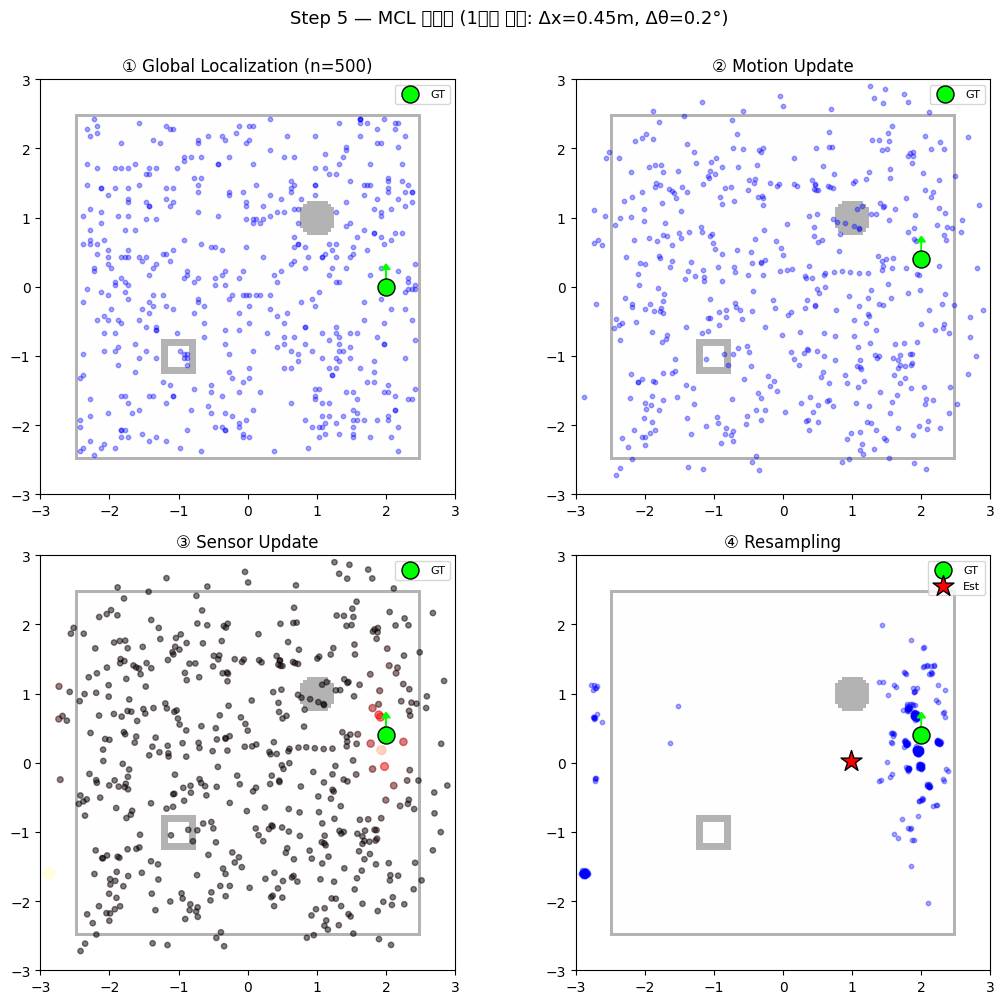

✅ Step 5 완료 — 한 스텝 MCL 단계별 분석
   GT 위치:     (2.00, 0.40)
   Est 위치:    (0.99, 0.02)
   오차:        1.083m
   최대 가중치: 0.1737
   최소 가중치: 0.000000


In [9]:
# 단계별 시각화
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
axes = axes.flatten()

def draw_step(ax, particles, title, gt=None, est=None, weights=None):
    draw_map(ax, title)
    if weights is not None:
        # 가중치에 따라 색상(빨강=높음, 검정=낮음)과 크기 변화
        ax.scatter(particles[:,0], particles[:,1], c=weights, cmap='hot',
                   s=15+weights*300, alpha=0.5, vmin=0, vmax=weights.max())
    else:
        ax.scatter(particles[:,0], particles[:,1], c='blue', s=10, alpha=0.35)
    if gt is not None:
        ax.scatter(gt[0], gt[1], c='lime', s=150, marker='o',
                   edgecolors='black', zorder=5, label='GT')
        ax.arrow(gt[0], gt[1], 0.25*np.cos(gt[2]), 0.25*np.sin(gt[2]),
                 head_width=0.12, head_length=0.08, fc='lime', ec='lime')
    if est is not None:
        ax.scatter(est[0], est[1], c='red', s=250, marker='*',
                   edgecolors='black', zorder=5, label='Est')
    ax.legend(loc='upper right', fontsize=8)

draw_step(axes[0], particles_step,
          f'① Global Localization (n={len(particles_step)})', gt=gt_before)
draw_step(axes[1], particles_motion,
          f'② Motion Update', gt=gt_after)
draw_step(axes[2], particles_motion,
          f'③ Sensor Update', gt=gt_after, weights=particles_weights)
draw_step(axes[3], particles_resampled,
          f'④ Resampling', gt=gt_after, est=[est_x, est_y])

plt.suptitle(
    f'Step 5 — MCL 단계별 ({STEP}번째 이동: '
    f'Δx={meas_delta[0]:.2f}m, Δθ={np.degrees(meas_delta[2]):.1f}°)',
    fontsize=13, y=1.00)
plt.tight_layout()
plt.show()

print(f"✅ Step 5 완료 — 한 스텝 MCL 단계별 분석")
print(f"   GT 위치:     ({gt_after[0]:.2f}, {gt_after[1]:.2f})")
print(f"   Est 위치:    ({est_x:.2f}, {est_y:.2f})")
print(f"   오차:        {np.hypot(est_x-gt_after[0], est_y-gt_after[1]):.3f}m")
print(f"   최대 가중치: {particles_weights.max():.4f}")
print(f"   최소 가중치: {particles_weights.min():.6f}")

## Step 6 — MCL 전체 루프 실행

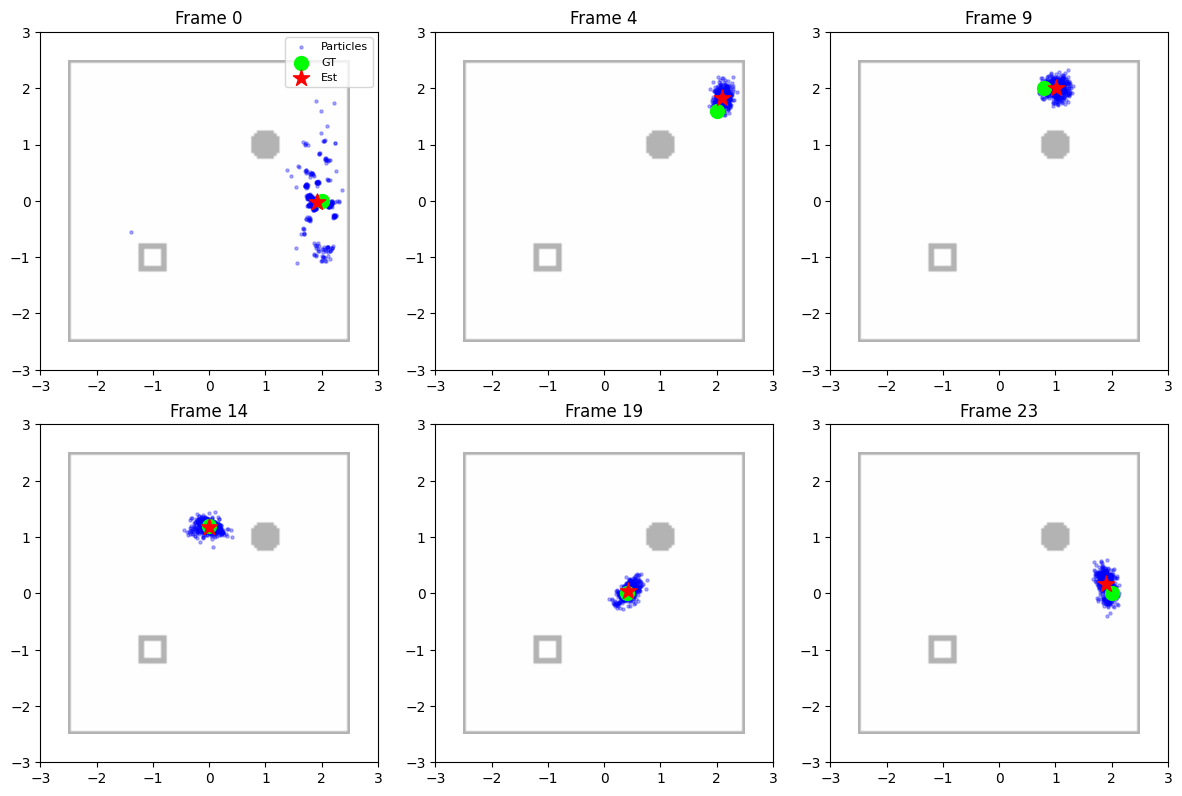

In [10]:
particles, weights = init_particles(500, grid=occupancy_grid)  # Global Localization: 맵 전체에 무작위 배포
history_frames = [0, 4, 9, 14, 19, len(gt_poses)-1]
history = []

for step in range(len(gt_poses)):
    if step > 0:
        # 1. Motion Update (Odometry)
        meas_delta = odom_deltas[step-1] if step-1 < len(odom_deltas) else relative_pose(gt_poses[step-1], gt_poses[step])
        particles = motion_update(particles, meas_delta)
    
    # 2. Sensor Update (LiDAR)
    particles_weights = sensor_update(particles, get_scan(gt_poses[step]), gt_poses[step])
    
    # 가중치 평균 위치 추정
    est_x, est_y = np.sum(particles[:,0]*particles_weights), np.sum(particles[:,1]*particles_weights)
    
    # 3. Resampling
    particles, _ = resample(particles, particles_weights)
    
    if step in history_frames:
        history.append({'pts': particles.copy(), 'est': [est_x, est_y], 'gt': gt_poses[step]})

# 시각화
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, h, frame in zip(axes.flatten(), history, history_frames):
    draw_map(ax, f"Frame {frame}")
    ax.scatter(h['pts'][:,0], h['pts'][:,1], c='blue', s=5, alpha=0.3, label='Particles')
    ax.scatter(*h['gt'][:2], c='lime', s=100, label='GT')
    ax.scatter(*h['est'], c='red', marker='*', s=150, label='Est')
    if frame == 0: ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()